Enter the query to search: Samsung Mobile
Enter number of pages to traverse: 2

Checking Page 1...
Products found on page: 22

Checking Page 2...
Products found on page: 19

Results Found: 5

Product: 1
Title : samsung
Price : ₹11499.00
Rating : 4.2 out of 5 stars
Review : N/A

Product: 2
Title : lava
Price : ₹8999.00
Rating : 3.5 out of 5 stars
Review : N/A

Product: 3
Title : redmi note 15 pro 5g (silver ash, 8gb+128gb) | 200masterpixel ois camera | dimensity 7400-ultra | 17.3cm crystalres amoled screen | ip66/68/69/69k | mega 6580mah si/c battery | 45w fast charging
Price : ₹31999.00
Rating : 3.9 out of 5 stars
Review : N/A

Product: 4
Title : redmi
Price : ₹44999.00
Rating : 4.3 out of 5 stars
Review : N/A

Product: 5
Title : oneplus
Price : ₹37999.00
Rating : 4.3 out of 5 stars
Review : N/A

Prices used for graph:
[11499.0, 8999.0, 31999.0, 44999.0, 37999.0]


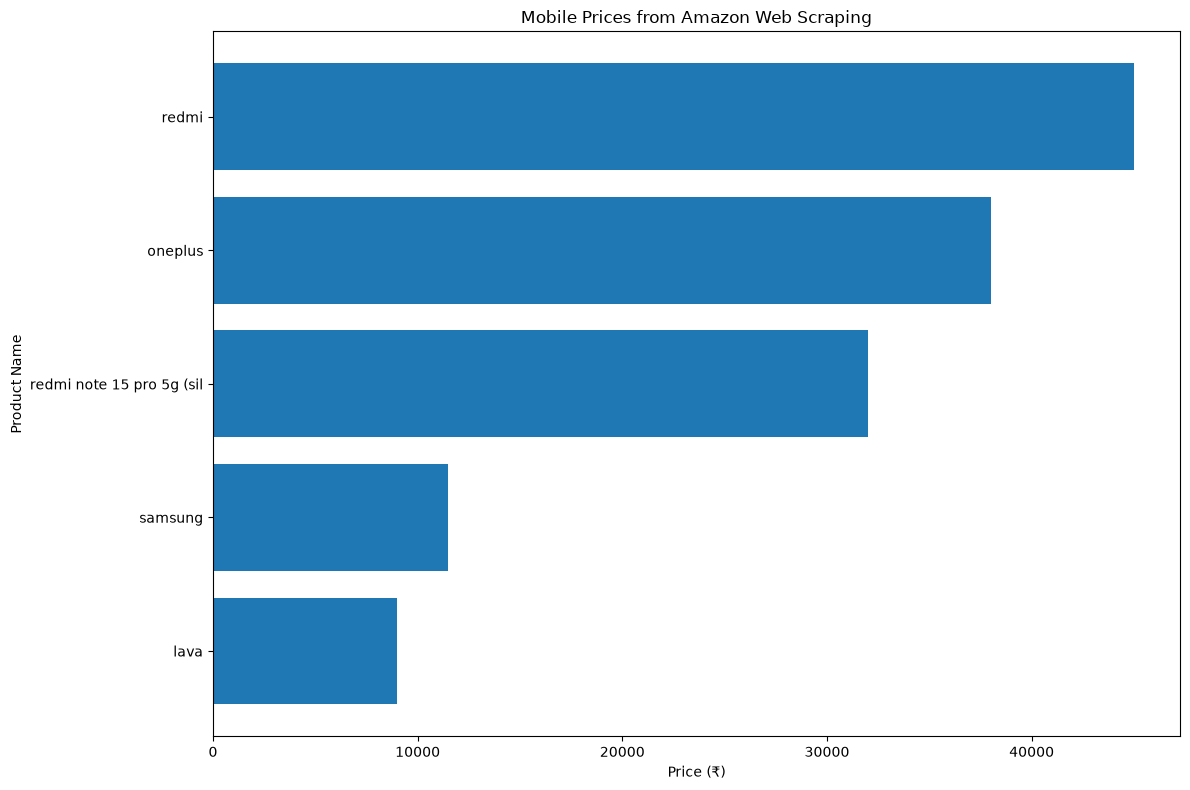

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import TimeoutException
import time
import matplotlib.pyplot as plt
import re

# --------------------------------
# INPUT
# --------------------------------

query = input("Enter the query to search: ").lower().strip()
pages = int(input("Enter number of pages to traverse: "))

found = []


# --------------------------------
# CHROME SETUP
# --------------------------------

options = Options()
options.add_argument("--start-maximized")
options.page_load_strategy = "eager"

driver = webdriver.Chrome(options=options)

driver.set_page_load_timeout(30)


# --------------------------------
# SEARCH AMAZON
# --------------------------------

for page in range(1, pages + 1):

    url = (
        "https://www.amazon.in/s?k="
        + query.replace(" ", "+")
        + "&page="
        + str(page)
    )

    print(f"\nChecking Page {page}...")

    try:
        driver.get(url)

    except TimeoutException:
        print("Page loading timed out. Continuing...")

    time.sleep(5)

    # Find Amazon product containers
    products = driver.find_elements(
        By.CSS_SELECTOR,
        'div[data-component-type="s-search-result"]'
    )

    print("Products found on page:", len(products))


    # --------------------------------
    # EXTRACT PRODUCT INFORMATION
    # --------------------------------

    for product in products:

        try:

            # Product title
            title = product.find_element(
                By.CSS_SELECTOR,
                "h2 span"
            ).text.strip().lower()


            # ----------------------------
            # PRODUCT PRICE
            # ----------------------------

            try:

                whole = product.find_element(
                    By.CSS_SELECTOR,
                    ".a-price-whole"
                ).get_attribute("textContent")

                whole = whole.strip().replace(",", "")

                try:
                    fraction = product.find_element(
                        By.CSS_SELECTOR,
                        ".a-price-fraction"
                    ).get_attribute("textContent")

                    fraction = fraction.strip()

                except:
                    fraction = "00"

                price = "₹" + whole + "." + fraction

            except:

                price = "Price not available"


            # ----------------------------
            # RATING
            # ----------------------------

            try:

                rating = product.find_element(
                    By.CSS_SELECTOR,
                    "span.a-icon-alt"
                ).get_attribute("textContent")

            except:

                rating = "N/A"


            # ----------------------------
            # REVIEWS
            # ----------------------------

            try:

                review = product.find_element(
                    By.CSS_SELECTOR,
                    "span.a-size-base.s-underline-text"
                ).text.strip()

            except:

                review = "N/A"


            # Store product
            found.append({
                "title": title,
                "price": price,
                "rating": rating,
                "review": review
            })


        except Exception:
            continue


    time.sleep(2)


# --------------------------------
# CLOSE AMAZON
# --------------------------------

driver.quit()


# --------------------------------
# REMOVE DUPLICATES
# --------------------------------

unique_products = []
seen = set()

for item in found:

    if item["title"] not in seen:

        seen.add(item["title"])
        unique_products.append(item)

found = unique_products


# --------------------------------
# DISPLAY RESULTS
# --------------------------------

print("\nResults Found:", len(found))
print()


for j, item in enumerate(found[:10], 1):

    print("Product:", j)
    print("Title :", item["title"])
    print("Price :", item["price"])
    print("Rating :", item["rating"])
    print("Review :", item["review"])
    print()


# --------------------------------
# PREPARE GRAPH DATA
# --------------------------------

if found:

    product_names = []
    product_prices = []

    for item in found[:10]:

        price_text = item["price"]

        # Remove ₹ and commas
        price_text = price_text.replace("₹", "")
        price_text = price_text.replace(",", "")
        price_text = price_text.strip()

        try:

            price = float(price_text)

            product_names.append(
                item["title"][:25]
            )

            product_prices.append(price)

        except:

            continue


    # --------------------------------
    # CHECK PRICE DATA
    # --------------------------------

    print("Prices used for graph:")
    print(product_prices)


    if product_prices:

        # Sort products by price
        data = sorted(
            zip(product_names, product_prices),
            key=lambda x: x[1]
        )

        product_names = [
            x[0] for x in data
        ]

        product_prices = [
            x[1] for x in data
        ]


        # --------------------------------
        # CREATE GRAPH
        # --------------------------------

        plt.figure(figsize=(12, 8))

        plt.barh(
            product_names,
            product_prices
        )

        plt.xlabel("Price (₹)")
        plt.ylabel("Product Name")

        plt.title(
            "Mobile Prices from Amazon Web Scraping"
        )

        plt.tight_layout()

        plt.show()


    else:

        print("No valid prices available for graph.")


else:

    print("No products found to plot.")